# Fraud Detection System with Real Time Simualtion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_ss = pd.read_csv(r'C:\Users\Akash\Desktop\self_made\Fraud_Detection_System_with_Real_Time_Simulation\sample_submission.csv')
data_testi = pd.read_csv(r'C:\Users\Akash\Desktop\self_made\Fraud_Detection_System_with_Real_Time_Simulation\test_identity.csv')
data_testt = pd.read_csv(r'C:\Users\Akash\Desktop\self_made\Fraud_Detection_System_with_Real_Time_Simulation\test_transaction.csv')
data_traini = pd.read_csv(r'C:\Users\Akash\Desktop\self_made\Fraud_Detection_System_with_Real_Time_Simulation\train_identity.csv')
data_traint = pd.read_csv(r'C:\Users\Akash\Desktop\self_made\Fraud_Detection_System_with_Real_Time_Simulation\train_transaction.csv')

In [3]:
data_ss

,TransactionID,isFraud
0,3663549,0.5
1,3663550,0.5
2,3663551,0.5
3,3663552,0.5
4,3663553,0.5
...,...,...
506686,4170235,0.5
506687,4170236,0.5
506688,4170237,0.5
506689,4170238,0.5


In [4]:
data_testi

,TransactionID,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663586,-45.0,280290.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
1,3663588,0.0,3579.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 67.0 for android,24.0,1280x720,match_status:2,T,F,T,T,mobile,LGLS676 Build/MXB48T
2,3663597,-5.0,185210.0,NaN,NaN,1.0,0.0,NaN,NaN,NaN,...,ie 11.0 for tablet,NaN,NaN,NaN,F,T,T,F,desktop,Trident/7.0
3,3663601,-45.0,252944.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
4,3663602,-95.0,328680.0,NaN,NaN,7.0,-33.0,NaN,NaN,NaN,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-G9650 Build/R16NW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141902,4170230,-20.0,473365.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,...,chrome 71.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-J700M
141903,4170233,-5.0,489917.0,0.0,0.0,-4.0,-32.0,NaN,NaN,0.0,...,chrome 71.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-J320M
141904,4170234,-5.0,110081.0,NaN,NaN,22.0,-31.0,NaN,NaN,NaN,...,mobile safari 10.0,32.0,1334x750,match_status:2,T,F,F,T,mobile,iOS Device
141905,4170236,-45.0,266704.0,NaN,NaN,-3.0,-10.0,NaN,NaN,NaN,...,chrome 43.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,ALE-L23 Build/HuaweiALE-L23


In [5]:
data_testt

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,3663549,18403224,31.950,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.000,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.000,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.950,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.950,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506686,4170235,34214279,94.679,C,13832,375.0,185.0,mastercard,224.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
506687,4170236,34214287,12.173,C,3154,408.0,185.0,mastercard,224.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
506688,4170237,34214326,49.000,W,16661,490.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
506689,4170238,34214337,202.000,W,16621,516.0,150.0,mastercard,224.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
data_traini

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144228,3577521,-15.0,145955.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 66.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,F3111 Build/33.3.A.1.97
144229,3577526,-5.0,172059.0,NaN,NaN,1.0,-5.0,NaN,NaN,NaN,...,chrome 55.0 for android,32.0,855x480,match_status:2,T,F,T,F,mobile,A574BL Build/NMF26F
144230,3577529,-20.0,632381.0,NaN,NaN,-1.0,-36.0,NaN,NaN,NaN,...,chrome 65.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,Moto E (4) Plus Build/NMA26.42-152
144231,3577531,-5.0,55528.0,0.0,0.0,0.0,-7.0,NaN,NaN,0.0,...,chrome 66.0,24.0,2560x1600,match_status:2,T,F,T,F,desktop,MacOS


In [7]:
data_testi

,TransactionID,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663586,-45.0,280290.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
1,3663588,0.0,3579.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 67.0 for android,24.0,1280x720,match_status:2,T,F,T,T,mobile,LGLS676 Build/MXB48T
2,3663597,-5.0,185210.0,NaN,NaN,1.0,0.0,NaN,NaN,NaN,...,ie 11.0 for tablet,NaN,NaN,NaN,F,T,T,F,desktop,Trident/7.0
3,3663601,-45.0,252944.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
4,3663602,-95.0,328680.0,NaN,NaN,7.0,-33.0,NaN,NaN,NaN,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-G9650 Build/R16NW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141902,4170230,-20.0,473365.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,...,chrome 71.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-J700M
141903,4170233,-5.0,489917.0,0.0,0.0,-4.0,-32.0,NaN,NaN,0.0,...,chrome 71.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-J320M
141904,4170234,-5.0,110081.0,NaN,NaN,22.0,-31.0,NaN,NaN,NaN,...,mobile safari 10.0,32.0,1334x750,match_status:2,T,F,F,T,mobile,iOS Device
141905,4170236,-45.0,266704.0,NaN,NaN,-3.0,-10.0,NaN,NaN,NaN,...,chrome 43.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,ALE-L23 Build/HuaweiALE-L23


In [8]:
data_ss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506691 entries, 0 to 506690
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  506691 non-null  int64  
 1   isFraud        506691 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 7.7 MB


In [9]:
data_traini.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  object 
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  object 
 16  id_16          129340 non-null  object 
 17  id_17          139369 non-nul

In [10]:
data_traint.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


In [11]:
data_testi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141907 entries, 0 to 141906
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  141907 non-null  int64  
 1   id-01          141907 non-null  float64
 2   id-02          136976 non-null  float64
 3   id-03          66481 non-null   float64
 4   id-04          66481 non-null   float64
 5   id-05          134750 non-null  float64
 6   id-06          134750 non-null  float64
 7   id-07          5059 non-null    float64
 8   id-08          5059 non-null    float64
 9   id-09          74338 non-null   float64
 10  id-10          74338 non-null   float64
 11  id-11          136778 non-null  float64
 12  id-12          141907 non-null  object 
 13  id-13          130286 non-null  float64
 14  id-14          71357 non-null   float64
 15  id-15          136977 non-null  object 
 16  id-16          125747 non-null  object 
 17  id-17          135966 non-nul

In [12]:
data_testt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506691 entries, 0 to 506690
Columns: 393 entries, TransactionID to V339
dtypes: float64(376), int64(3), object(14)
memory usage: 1.5+ GB


In [13]:
data_ss.shape

(506691, 2)

In [14]:
data_traini.shape

(144233, 41)

In [15]:
data_traint.shape

(590540, 394)

In [16]:
data_testi.shape

(141907, 41)

In [17]:
data_testt.shape

(506691, 393)

In [18]:
data_ss.describe()

,TransactionID,isFraud
count,5.066910e+05,506691.0
mean,3.916894e+06,0.5
std,1.462692e+05,0.0
min,3.663549e+06,0.5
25%,3.790222e+06,0.5
50%,3.916894e+06,0.5
75%,4.043566e+06,0.5
max,4.170239e+06,0.5


In [19]:
data_traini.describe()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,1.442330e+05,144233.000000,140872.000000,66324.000000,66324.000000,136865.000000,136865.000000,5155.000000,5155.000000,74926.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.236329e+06,-10.170502,174716.584708,0.060189,-0.058938,1.615585,-6.698710,13.285354,-38.600388,0.091023,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.788496e+05,14.347949,159651.816856,0.598231,0.701015,5.249856,16.491104,11.384207,26.084899,0.983842,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987004e+06,-100.000000,1.000000,-13.000000,-28.000000,-72.000000,-100.000000,-46.000000,-100.000000,-36.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.077142e+06,-10.000000,67992.000000,0.000000,0.000000,0.000000,-6.000000,5.000000,-48.000000,0.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.198818e+06,-5.000000,125800.500000,0.000000,0.000000,0.000000,0.000000,14.000000,-34.000000,0.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.392923e+06,-5.000000,228749.000000,0.000000,0.000000,1.000000,0.000000,22.000000,-23.000000,0.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577534e+06,0.000000,999595.000000,10.000000,0.000000,52.000000,0.000000,61.000000,0.000000,25.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


In [20]:
data_traint.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.00000,82351.000000,82351.000000,82351.000000,82351.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,0.775874,721.741883,1375.783644,1014.622782,9.807015,59.16455,28.530903,55.352422,151.160542,100.700882
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,4.727971,6217.223583,11169.275702,7955.735482,243.861391,387.62948,274.576920,668.486833,1095.034387,814.946722
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,0.000000,0.000000,25.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,55.000000,160000.000000,160000.000000,160000.000000,55125.000000,55125.00000,55125.000000,104060.000000,104060.000000,104060.000000


In [21]:
data_testi.describe()

,TransactionID,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,...,id-17,id-18,id-19,id-20,id-21,id-22,id-24,id-25,id-26,id-32
count,1.419070e+05,141907.000000,136976.000000,66481.000000,66481.000000,134750.000000,134750.000000,5059.000000,5059.000000,74338.000000,...,135966.000000,50875.000000,135906.000000,135633.000000,5059.000000,5062.000000,4740.000000,5039.000000,5047.000000,70671.000000
mean,3.972166e+06,-11.325734,192658.729909,0.053008,-0.087454,1.246033,-6.803829,12.493180,-36.577782,0.076219,...,191.070341,14.795735,350.122982,408.886230,507.727021,15.336823,13.166667,332.043064,152.752923,26.217939
std,1.469966e+05,14.508520,182613.277215,0.684551,0.840351,5.071394,15.921457,11.678206,25.544185,1.009687,...,30.749535,2.318496,139.140824,158.971756,227.371061,5.618032,3.222440,86.356683,31.916995,3.601046
min,3.663586e+06,-100.000000,2.000000,-12.000000,-19.000000,-81.000000,-100.000000,-41.000000,-100.000000,-32.000000,...,100.000000,11.000000,100.000000,100.000000,100.000000,11.000000,10.000000,100.000000,100.000000,8.000000
25%,3.859268e+06,-12.500000,63339.500000,0.000000,0.000000,0.000000,-6.000000,3.000000,-46.000000,0.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,137.000000,24.000000
50%,4.001774e+06,-5.000000,133189.500000,0.000000,0.000000,0.000000,0.000000,12.000000,-33.000000,0.000000,...,166.000000,15.000000,321.000000,484.000000,576.000000,14.000000,11.000000,321.000000,147.000000,24.000000
75%,4.105284e+06,-5.000000,265717.500000,0.000000,0.000000,1.000000,0.000000,21.000000,-23.000000,0.000000,...,225.000000,15.000000,427.000000,549.000000,711.000000,14.000000,15.000000,355.000000,182.000000,32.000000
max,4.170239e+06,0.000000,999869.000000,11.000000,0.000000,52.000000,0.000000,59.000000,0.000000,16.000000,...,228.000000,29.000000,670.000000,660.000000,854.000000,44.000000,26.000000,549.000000,216.000000,48.000000


In [22]:
data_testt.describe()

,TransactionID,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,5.066910e+05,5.066910e+05,506691.000000,506691.000000,498037.000000,503689.000000,502144.000000,441082.000000,441082.000000,215474.000000,...,76431.000000,7.643100e+04,7.643100e+04,7.643100e+04,76431.000000,76431.000000,76431.000000,76431.000000,76431.000000,76431.000000
mean,3.916894e+06,2.692994e+07,134.725568,9957.222175,363.735379,153.543409,200.162975,291.846514,86.723412,87.065270,...,0.309900,3.151286e+02,4.404643e+02,3.811021e+02,24.708030,58.339468,35.485643,99.058760,155.578153,139.814706
std,1.462692e+05,4.756507e+06,245.779822,4884.960969,158.688653,12.443013,40.562461,102.062730,2.987328,314.131694,...,2.632181,9.494045e+03,1.064843e+04,1.039556e+04,842.913287,990.361078,904.093921,2436.074522,4544.303974,4493.728267
min,3.663549e+06,1.840322e+07,0.018000,1001.000000,100.000000,100.000000,100.000000,100.000000,10.000000,0.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.790222e+06,2.277154e+07,40.000000,6019.000000,207.000000,150.000000,166.000000,204.000000,87.000000,3.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.916894e+06,2.720466e+07,67.950000,9803.000000,369.000000,150.000000,226.000000,299.000000,87.000000,8.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.043566e+06,3.134856e+07,125.000000,14276.000000,512.000000,150.000000,226.000000,330.000000,87.000000,20.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,4.170239e+06,3.421434e+07,10270.000000,18397.000000,600.000000,232.000000,237.000000,540.000000,102.000000,8081.000000,...,106.000000,1.040658e+06,1.040658e+06,1.040658e+06,64800.000000,64800.000000,64800.000000,375000.000000,612500.000000,612500.000000


In [23]:
data_ss.isnull().sum()

TransactionID    0
isFraud          0
dtype: int64

In [24]:
data_traint.isnull().sum()

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
V335              508189
V336              508189
V337              508189
V338              508189
V339              508189
Length: 394, dtype: int64

In [25]:
data_traini.isnull().sum()

TransactionID         0
id_01                 0
id_02              3361
id_03             77909
id_04             77909
id_05              7368
id_06              7368
id_07            139078
id_08            139078
id_09             69307
id_10             69307
id_11              3255
id_12                 0
id_13             16913
id_14             64189
id_15              3248
id_16             14893
id_17              4864
id_18             99120
id_19              4915
id_20              4972
id_21            139074
id_22            139064
id_23            139064
id_24            139486
id_25            139101
id_26            139070
id_27            139064
id_28              3255
id_29              3255
id_30             66668
id_31              3951
id_32             66647
id_33             70944
id_34             66428
id_35              3248
id_36              3248
id_37              3248
id_38              3248
DeviceType         3423
DeviceInfo        25567
dtype: int64

In [26]:
data_testi.isnull().sum()

TransactionID         0
id-01                 0
id-02              4931
id-03             75426
id-04             75426
id-05              7157
id-06              7157
id-07            136848
id-08            136848
id-09             67569
id-10             67569
id-11              5129
id-12                 0
id-13             11621
id-14             70550
id-15              4930
id-16             16160
id-17              5941
id-18             91032
id-19              6001
id-20              6274
id-21            136848
id-22            136845
id-23            136845
id-24            137167
id-25            136868
id-26            136860
id-27            136845
id-28              5129
id-29              5129
id-30             71248
id-31              5282
id-32             71236
id-33             71236
id-34             69732
id-35              4930
id-36              4930
id-37              4930
id-38              4930
DeviceType         4976
DeviceInfo        26850
dtype: int64

In [27]:
data_testt.isnull().sum()

TransactionID          0
TransactionDT          0
TransactionAmt         0
ProductCD              0
card1                  0
                   ...  
V335              430260
V336              430260
V337              430260
V338              430260
V339              430260
Length: 393, dtype: int64

In [28]:

import pandas as pd

df = pd.read_csv('train_transaction.csv', usecols=['isFraud'])

fraud_count = df['isFraud'].sum()
legit_count = len(df) - fraud_count

print("Legit:", legit_count)
print("Fraud:", fraud_count)
print("Fraud %:", round(fraud_count/len(df)*100, 2))

ratio = legit_count / fraud_count
print("Imbalance ratio:", round(ratio, 1), ": 1")

Legit: 569877
Fraud: 20663
Fraud %: 3.5
Imbalance ratio: 27.6 : 1


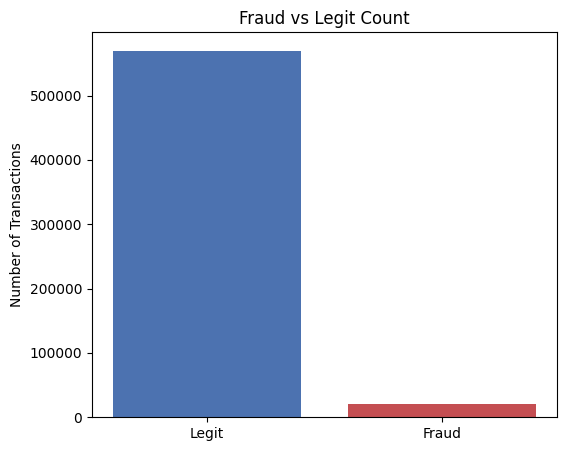

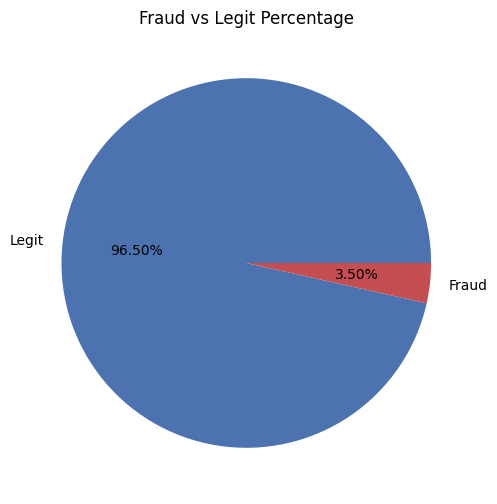

In [29]:
fraud_count = data_traint['isFraud'].sum()
legit_count = len(data_traint) - fraud_count

labels = ['Legit', 'Fraud']
values = [legit_count, fraud_count]

plt.figure(figsize=(6,5))
plt.bar(labels, values, color = ['#4C72B0', '#C44E52'])
plt.title('Fraud vs Legit Count')
plt.ylabel('Number of Transactions')
plt.show()

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.2f%%', colors = ['#4C72B0', '#C44E52'])
plt.title('Fraud vs Legit Percentage')
plt.show()

In [30]:
trans = pd.read_csv('train_transaction.csv')
identity = pd.read_csv('train_identity.csv')

df = trans.merge(identity, on='TransactionID', how='left')

print(df.shape)
print(df['isFraud'].value_counts())

(590540, 434)
isFraud
0    569877
1     20663
Name: count, dtype: int64


In [31]:
identity.shape

(144233, 41)

In [32]:
trans.shape

(590540, 394)

In [33]:
missing_percent = df.isnull().mean() * 100

cols_to_drop = missing_percent[missing_percent > 90].index.tolist()
print("columns to drop:", len(cols_to_drop))
print(cols_to_drop)

df = df.drop(columns=cols_to_drop)
print(df.shape)

columns to drop: 12
['dist2', 'D7', 'id_07', 'id_08', 'id_18', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27']
(590540, 422)


In [34]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('isFraud')
numeric_cols.remove('TransactionID')

correlations = df[numeric_cols].corrwith(df['isFraud'])
correlations = correlations.abs().sort_values(ascending=False)

print(correlations.head(50))

V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
V157    0.234866
V155    0.234199
V230    0.231740
V199    0.231024
V148    0.228891
V51     0.223191
V171    0.216508
V40     0.212442
V243    0.210238
V154    0.206958
V190    0.205148
V39     0.203097
V38     0.199005
V146    0.198584
V43     0.198274
V140    0.196938
V79     0.194141
V42     0.189428
V94     0.188407
V74     0.185915
V33     0.183486
V153    0.183114
V17     0.182673
V18     0.182550
V81     0.182377
V93     0.180983
V92     0.180513
V34     0.180301
V80     0.180299
V50     0.179953
dtype: float64


In [35]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(col)
    print(df.groupby(col)['isFraud'].mean().sort_values(ascending=False))
    print("missing %:", df[col].isnull().mean()*100)
    print("-----")

ProductCD
ProductCD
C    0.116873
S    0.058996
H    0.047662
R    0.037826
W    0.020399
Name: isFraud, dtype: float64
missing %: 0.0
-----
card4
card4
discover            0.077282
visa                0.034756
mastercard          0.034331
american express    0.028698
Name: isFraud, dtype: float64
missing %: 0.267043722694483
-----
card6
card6
credit             0.066785
debit              0.024263
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64
missing %: 0.26602770345785215
-----
P_emaildomain
P_emaildomain
protonmail.com      0.407895
mail.com            0.189624
outlook.es          0.130137
aim.com             0.126984
outlook.com         0.094584
hotmail.es          0.065574
live.com.mx         0.054740
hotmail.com         0.052950
gmail.com           0.043542
yahoo.fr            0.034965
embarqmail.com      0.034615
mac.com             0.032110
icloud.com          0.031434
comcast.net         0.031187
charter.net         0.030637
frontier.com

strong, clean signal:

- ProductCD — fraud rate ranges from 2% (W) to 11.7% (C), 0% missing. Definitely keep.
- card4, card6 — card type/network clearly separates fraud rate (credit cards riskier than debit, discover riskier than others). Keep.
- DeviceType — mobile (10.2% fraud) vs desktop (6.5% fraud), a real gap. Keep.
- M4 — M2 category has 11.4% fraud vs M0/M1 around 3%. Worth keeping.
- id_15, id_16, id_29, id_35, id_36, id_38 — all show a clear "Found vs NotFound" or True/False split with meaningfully different fraud rates. Keep these.

potentially useful

- P_emaildomain and R_emaildomain show very different fraud rates. Some categories, such as protonmail.com, have very high fraud rates. However, many of these categories have only a few transactions, so the high fraud rates may not be reliable. For example, a fraud rate of 1.0 may simply mean there was only one transaction, and it was fraud. So, we should group categories with very few transactions into an **"Other"** category instead of trusting these extreme fraud rates.



Not very useful:

- M1, M2, M3, M5, M6, M7, M8, M9 — T/F fraud rates are close to each other (like 3.7% vs 2.6%), weak separation. Lower priority, but not necessarily worth dropping since they're cheap to include.

OUT OF 29 CATEGORICAL COLUMNS WE HAVE REMOVED 12 COLUMNS AND KEPT 17.

In [36]:
cat_cols_keep = ['ProductCD','card4','card6','P_emaildomain','R_emaildomain',
                  'M4','DeviceType','id_12','id_15','id_16','id_28','id_29',
                  'id_34','id_35','id_36','id_37','id_38']   

cat_cols_drop = ['M1','M2','M3','M5','M6','M7','M8','M9',
                  'id_30','id_31','id_33','DeviceInfo']       

df = df.drop(columns=cat_cols_drop)
print(df.shape)

(590540, 410)


In [37]:
correlations = df[numeric_cols].corrwith(df['isFraud'])
correlations = correlations.abs().sort_values(ascending=False)

for cutoff in [0.02, 0.05, 0.08, 0.1, 0.15]:
    n = (correlations > cutoff).sum()
    print("cutoff", cutoff, "-> columns kept:", n)

cutoff 0.02 -> columns kept: 257
cutoff 0.05 -> columns kept: 169
cutoff 0.08 -> columns kept: 125
cutoff 0.1 -> columns kept: 117
cutoff 0.15 -> columns kept: 80


- 0.02 is too loose — 257 columns is still basically "keep almost everything," which defeats the purpose of reducing features. 0.15 might be too aggressive and could cut features that still add value when combined with others in a tree-based model (correlation only measures individual linear relationship, not what a model can do combining several weak features together).

In [38]:
cutoff = 0.05
numeric_keep = correlations[correlations > cutoff].index.tolist()

print("numeric columns kept by correlation:", len(numeric_keep))

# domain-important columns we keep regardless of correlation score
must_keep = ['TransactionAmt','TransactionDT','card1','card2','card3','card5',
             'addr1','addr2','dist1']

added = [col for col in must_keep if col not in numeric_keep]
print("must-keep columns not already in list:", added)

numeric_keep = numeric_keep + added
print("final numeric columns:", len(numeric_keep))

numeric columns kept by correlation: 169
must-keep columns not already in list: ['TransactionAmt', 'TransactionDT', 'card1', 'card2', 'card5', 'addr1', 'addr2', 'dist1']
final numeric columns: 177


Good — 177 final numeric columns, with 7 of the 9 must-keep columns getting added on top of the correlation list ( card3 wasn't in the "not already in list" output, meaning it was already captured by correlation; dist1 also wasn't in that list so it's already there too). Nice, minimal redundancy.

Before finalizing the numeric column list, let's explicitly decide the train/test split strategy (time-based), since that affects whether we should redo the correlation check properly on train-only data.

Time-based train/test split

- Since TransactionDT is a time offset (seconds from a reference point, not a real date), we sort by it and split so the model trains on earlier transactions and tests on later ones — just like it would work in real deployment.

In [39]:
df = df.sort_values('TransactionDT')

split_point = int(len(df) * 0.8)

train_df = df.iloc[:split_point]
test_df = df.iloc[split_point:]

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)

print("train fraud rate:", train_df['isFraud'].mean())
print("test fraud rate:", test_df['isFraud'].mean())

print("train date range:", train_df['TransactionDT'].min(), "to", train_df['TransactionDT'].max())
print("test date range:", test_df['TransactionDT'].min(), "to", test_df['TransactionDT'].max())

train shape: (472432, 410)
test shape: (118108, 410)
train fraud rate: 0.03513521522674162
test fraud rate: 0.034409184813899145
train date range: 86400 to 12192842
test date range: 12192900 to 15811131


we still need to redo the correlation check using only train_df instead of the full df, because right now our correlation numbers were computed using test data too — which quietly "peeked" at data the model shouldn't see yet during feature selection.

In [40]:
numeric_cols = train_df.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('isFraud')
numeric_cols.remove('TransactionID')

correlations = train_df[numeric_cols].corrwith(train_df['isFraud'])
correlations = correlations.abs().sort_values(ascending=False)

cutoff = 0.05
numeric_keep = correlations[correlations > cutoff].index.tolist()
print("numeric columns kept by correlation:", len(numeric_keep))

must_keep = ['TransactionAmt','TransactionDT','card1','card2','card3','card5',
             'addr1','addr2','dist1']

added = [col for col in must_keep if col not in numeric_keep]
print("must-keep columns not already in list:", added)

numeric_keep = numeric_keep + added
print("final numeric columns:", len(numeric_keep))

numeric columns kept by correlation: 197
must-keep columns not already in list: ['TransactionAmt', 'TransactionDT', 'card1', 'card2', 'card5', 'addr1', 'addr2', 'dist1']
final numeric columns: 205


We're now at 205 final numeric columns + 17 categorical columns as our working feature set going into modeling. That's a lot more manageable than the original 434.

Next natural step would be to actually build the modeling dataframe (numeric_keep + cat_cols_keep + isFraud, sliced from train_df and test_df) and start handling missing values before we can train anything.

In [41]:
feature_cols = numeric_keep + cat_cols_keep

X_train = train_df[feature_cols]
y_train = train_df['isFraud']

X_test = test_df[feature_cols]
y_test = test_df['isFraud']

print(X_train.shape)
print(X_test.shape)

print("missing values in X_train:")
print(X_train.isnull().sum().sum())

(472432, 222)
(118108, 222)
missing values in X_train:
48082200


missingness itself carries a fraud signal (remember: 7.85% fraud rate with identity data vs 2.09% without) — we don't want to simply average away the NaNs. If we fill with mean/median, we destroy that signal. The common approach for fraud data like this is to fill with a sentinel value that's clearly outside the normal range, so the model can still tell "this was missing" apart from a real value.

In [42]:
X_train_filled = X_train.copy()
X_test_filled = X_test.copy()

numeric_cols_final = numeric_keep
cat_cols_final = cat_cols_keep

for col in numeric_cols_final:
    X_train_filled[col] = X_train_filled[col].fillna(-999)
    X_test_filled[col] = X_test_filled[col].fillna(-999)

for col in cat_cols_final:
    X_train_filled[col] = X_train_filled[col].fillna('missing')
    X_test_filled[col] = X_test_filled[col].fillna('missing')

print("missing in train after fill:", X_train_filled.isnull().sum().sum())
print("missing in test after fill:", X_test_filled.isnull().sum().sum())

missing in train after fill: 0
missing in test after fill: 0


Why -999 for numeric columns: none of our numeric columns (amounts, counts, engineered V-features) naturally go negative into the hundreds, so -999 is a value the model will never confuse with a real one. Tree-based models (which we're planning to use — XGBoost/LightGBM/RF) can easily learn "if this feature is around -999, treat it differently," effectively learning from missingness instead of losing it.

In [43]:
from sklearn.preprocessing import LabelEncoder

X_train_encoded = X_train_filled.copy()
X_test_encoded = X_test_filled.copy()

for col in cat_cols_final:
    le = LabelEncoder()
    combined = pd.concat([X_train_encoded[col], X_test_encoded[col]], axis=0)
    le.fit(combined)
    X_train_encoded[col] = le.transform(X_train_encoded[col])
    X_test_encoded[col] = le.transform(X_test_encoded[col])

print(X_train_encoded.dtypes.value_counts())
print(X_train_encoded.shape)

float64    203
int64       19
Name: count, dtype: int64
(472432, 222)


Why we fit on train+test combined: if a category (like a rare email domain) only appears in test but not train, LabelEncoder would throw an error when transforming test data on an encoder that never saw it. Combining them for fitting avoids that crash — a common practical workaround, not a leakage issue, since we're not using any label (isFraud) here, just the category names themselves.

# Preprocessing is fully done now

Data is clean, split correctly by time, features selected, missing values handled meaningfully, and everything is numeric. This is roughly the halfway point of the overall project (data prep phase complete; modeling, SQL, simulation, and dashboard are still ahead), so consider this your 50% checkpoint reminder as promised earlier.

# Next step: handling class imbalance and training the first baseline model.

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(scale_pos_weight=(y_train.value_counts()[0]/y_train.value_counts()[1])),
    'LightGBM': LGBMClassifier(class_weight='balanced')
}

for name, model in models.items():
    model.fit(X_train_encoded, y_train)
    probs = model.predict_proba(X_test_encoded)[:,1]
    preds = model.predict(X_test_encoded)
    
    auc = roc_auc_score(y_test, probs)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    print(name)
    print("ROC-AUC:", auc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print("-----")

c:\Users\Akash\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
ROC-AUC: 0.7739121881435732
Precision: 0.08620474016634357
Recall: 0.6783956692913385
F1: 0.1529712034622427
-----
Random Forest
ROC-AUC: 0.8785010769603498
Precision: 0.8725182863113897
Recall: 0.20546259842519685
F1: 0.33260306711810395
-----
XGBoost
ROC-AUC: 0.8757398578912214
Precision: 0.19486958396206078
Recall: 0.6673228346456693
F1: 0.3016517435070352
-----
[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.306916 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10260
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 222
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM
ROC-AUC: 0.8850043752970603
Precision: 0.16


| Model | ROC-AUC | Precision | Recall | F1 |
| :--- | :--- | :--- | :--- | :--- |
| Logistic Regression | 0.774 | 0.086 | 0.678 | 0.153 |
| Random Forest | 0.879 | 0.873 | 0.205 | 0.333 |
| XGBoost | 0.876 | 0.195 | 0.667 | 0.302 |
| LightGBM | **0.885** | 0.163 | 0.734 | 0.267 |


- LightGBM has the best ROC-AUC (0.885) — best at ranking fraud vs non-fraud overall, and highest recall (73.4% of actual fraud caught)
- Random Forest is the opposite extreme — very high precision (87.3%, meaning when it says "fraud" it's almost always right) but terrible recall (only 20.5% of fraud actually caught) — it's being too conservative, missing most fraud
- Logistic Regression is the weakest — makes sense, since it's a linear model and this dataset has messy, non-linear relationships (V-columns, categorical interactions) that tree-based models capture much better. Also threw a convergence warning — not dangerous, just means it didn't fully optimize (we could fix with feature scaling, but low priority since it's not our best model anyway)
- XGBoost sits in between — good recall (66.7%), weak precision (19.5%)

All 4 models' precision looks low-ish at default threshold — that's expected and normal for a 27.6:1 imbalance, not a sign of a broken model.

Next step: threshold tuning with a business cost function

- False Negative cost = the fraud amount itself (we lose the transaction amount, TransactionAmt, when we miss real fraud)
- False Positive cost = cost of wrongly blocking/investigating a legitimate transaction (a flat operational cost, e.g. customer service time, friction, lost trust

# Cost Function

Let's build the cost function and tune thresholds for each model.

In [45]:
fraud_amt_test = X_test['TransactionAmt'].values

fp_cost = 5

def business_cost(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    fn_mask = (y_true == 1) & (preds == 0)
    fp_mask = (y_true == 0) & (preds == 1)
    
    fn_cost = fraud_amt_test[fn_mask].sum()
    fp_cost_total = fp_mask.sum() * fp_cost
    
    return fn_cost + fp_cost_total

thresholds = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for name, model in models.items():
    probs = model.predict_proba(X_test_encoded)[:,1]
    print(name)
    for t in thresholds:
        cost = business_cost(y_test.values, probs, t)
        print("threshold", t, "-> cost:", cost)
    print("-----")

Logistic Regression
threshold 0.05 -> cost: 570220.0
threshold 0.1 -> cost: 570215.0
threshold 0.15 -> cost: 569375.0
threshold 0.2 -> cost: 554631.8
threshold 0.3 -> cost: 478947.701
threshold 0.4 -> cost: 343670.731
threshold 0.5 -> cost: 344225.435
threshold 0.6 -> cost: 382974.69299999997
threshold 0.7 -> cost: 432336.984
-----
Random Forest
threshold 0.05 -> cost: 233734.332
threshold 0.1 -> cost: 281403.657
threshold 0.15 -> cost: 341776.853
threshold 0.2 -> cost: 388768.964
threshold 0.3 -> cost: 452199.579
threshold 0.4 -> cost: 497104.976
threshold 0.5 -> cost: 524623.69
threshold 0.6 -> cost: 549408.849
threshold 0.7 -> cost: 566474.448
-----
XGBoost
threshold 0.05 -> cost: 434193.923
threshold 0.1 -> cost: 352101.166
threshold 0.15 -> cost: 304856.817
threshold 0.2 -> cost: 272410.20499999996
threshold 0.3 -> cost: 242751.902
threshold 0.4 -> cost: 238393.096
threshold 0.5 -> cost: 254664.238
threshold 0.6 -> cost: 279982.74299999996
threshold 0.7 -> cost: 322559.57999999996

- False Negative cost = the actual transaction amount. If we miss real fraud, the bank/company loses that money directly — this is the most realistic FN cost we can use without inventing numbers, since we already have TransactionAmt in the data.

- False Positive cost = flat $5. Wrongly flagging a legit transaction doesn't lose money directly, but it costs something — a customer service call, a temporary block, friction/annoyance. $5 is a placeholder representing that operational cost. It's much smaller than typical fraud amounts on purpose, since falsely blocking someone is annoying but recoverable, while missing fraud is a direct financial loss.

This is a "blanket-flag-everyone" sanity check waiting to happen


| Model | Best threshold | Cost |
| :--- | :--- | :--- |
| Logistic Regression | 0.4 | \$343,671 |
| Random Forest | 0.05 | \$233,734 |
| XGBoost | 0.4 | \$238,393 |
| LightGBM | **0.4** | **\$226,115** |


Let's make sure a "flag everyone" or "flag no one" baseline isn't secretly cheaper than our tuned models.

In [46]:
legit_count_test = (y_test == 0).sum()
fraud_amt_sum = X_test.loc[y_test == 1, 'TransactionAmt'].sum()

blanket_flag_cost = legit_count_test * fp_cost
flag_nobody_cost = fraud_amt_sum

print("blanket flag everyone cost:", blanket_flag_cost)
print("flag nobody cost:", flag_nobody_cost)

blanket flag everyone cost: 570220
flag nobody cost: 609934.336


# Best Model - LightGBM


LightGBM at threshold 0.4 cuts cost by roughly 63% compared to flagging nobody, and 60% compared to blanket-flagging everyone. That's a strong, legitimate result. LightGBM is our best model + threshold combo.

Now let's Save the Model

In [47]:
import joblib

best_model = models['LightGBM']

joblib.dump(best_model, 'fraud_model.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')
joblib.dump(cat_cols_final, 'cat_cols.pkl')

encoders = {}
for col in cat_cols_final:
    le = LabelEncoder()
    combined = pd.concat([X_train[col].fillna('missing'), X_test[col].fillna('missing')], axis=0)
    le.fit(combined)
    encoders[col] = le

joblib.dump(encoders, 'encoders.pkl')

print("saved")

saved


- We're saving best_model = the already-trained LightGBM model object directly, not retraining it.
- feature_cols (the 222 column names in the right order) is saved separately.

# Modeling phase Completed

# Next step: SQLite database design.

what tables we actually need for this to feel like a real system:

- transactions — stores incoming transactions as they arrive (the raw data we'd realistically have access to at prediction time, not the training columns like isFraud which we won't know for real new transactions)
- predictions — stores what our model said about each transaction (fraud probability, predicted label at our chosen 0.4 threshold, timestamp)

In [ ]:
import sqlite3

conn = sqlite3.connect('fraud_detection.db')
cur = conn.cursor()

cur.execute('''
CREATE TABLE IF NOT EXISTS transactions (
    TransactionID INTEGER PRIMARY KEY,
    TransactionDT INTEGER,
    TransactionAmt REAL,
    ProductCD TEXT,
    card4 TEXT,
    card6 TEXT,
    DeviceType TEXT,
    received_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
''')

cur.execute('''
CREATE TABLE IF NOT EXISTS predictions (
    TransactionID INTEGER,
    fraud_probability REAL,
    predicted_label INTEGER,
    scored_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    FOREIGN KEY (TransactionID) REFERENCES transactions(TransactionID)
)
''')

conn.commit()
conn.close()

print("database created")

database created


In [51]:
import joblib
import sqlite3
import time
import pandas as pd

model = joblib.load('fraud_model.pkl')
feature_cols = joblib.load('feature_cols.pkl')
cat_cols = joblib.load('cat_cols.pkl')
encoders = joblib.load('encoders.pkl')

conn = sqlite3.connect('fraud_detection.db')

sample_transactions = X_test.sample(20, random_state=1)

for idx, row in sample_transactions.iterrows():

    txn = row.copy()

    cur = conn.cursor()
    cur.execute('''
    INSERT OR REPLACE INTO transactions (TransactionID, TransactionDT, TransactionAmt, ProductCD, card4, card6, DeviceType)
    VALUES (?, ?, ?, ?, ?, ?, ?)
    ''', (int(idx), int(txn['TransactionDT']), float(txn['TransactionAmt']),
          str(txn['ProductCD']), str(txn['card4']), str(txn['card6']), str(txn['DeviceType'])))

    model_input = txn[feature_cols].copy()

    for col in cat_cols:
        val = model_input[col]
        if pd.isnull(val):
            val = 'missing'
        le = encoders[col]
        model_input[col] = le.transform([val])[0]

    numeric_cols_input = [c for c in feature_cols if c not in cat_cols]
    for col in numeric_cols_input:
        if pd.isnull(model_input[col]):
            model_input[col] = -999

    model_input_df = pd.DataFrame([model_input])[feature_cols]

    prob = model.predict_proba(model_input_df)[:,1][0]
    label = int(prob >= 0.4)

    cur.execute('''
    INSERT INTO predictions (TransactionID, fraud_probability, predicted_label)
    VALUES (?, ?, ?)
    ''', (int(idx), float(prob), label))

    conn.commit()

    print("TransactionID:", idx, "| prob:", round(prob,4), "| flagged:", label)

    time.sleep(1)

conn.close()
print("simulation done")

TransactionID: 503376 | prob: 0.0726 | flagged: 0
TransactionID: 511662 | prob: 0.0518 | flagged: 0
TransactionID: 522917 | prob: 0.2277 | flagged: 0
TransactionID: 565396 | prob: 0.4625 | flagged: 1
TransactionID: 565857 | prob: 0.244 | flagged: 0
TransactionID: 521766 | prob: 0.5967 | flagged: 1
TransactionID: 493191 | prob: 0.0845 | flagged: 0
TransactionID: 561886 | prob: 0.2121 | flagged: 0
TransactionID: 523067 | prob: 0.1737 | flagged: 0
TransactionID: 499270 | prob: 0.0415 | flagged: 0
TransactionID: 488231 | prob: 0.0432 | flagged: 0
TransactionID: 503061 | prob: 0.4598 | flagged: 1
TransactionID: 474538 | prob: 0.0643 | flagged: 0
TransactionID: 583805 | prob: 0.9942 | flagged: 1
TransactionID: 564419 | prob: 0.1434 | flagged: 0
TransactionID: 578590 | prob: 0.1976 | flagged: 0
TransactionID: 499005 | prob: 0.3234 | flagged: 0
TransactionID: 568933 | prob: 0.4893 | flagged: 1
TransactionID: 526473 | prob: 0.5328 | flagged: 1
TransactionID: 519516 | prob: 0.1296 | flagged: 0
s